# 6CS012 – Final Portfolio Assessment 2026
## Part II: Image Classification with Convolutional Neural Networks
### Traffic Sign Classification (Caution | Instructions | No Passing | OverSpeed)
**Herald College Kathmandu – University of Wolverhampton**

---
## Cell 1 — Install & Import Libraries

In [ ]:
# ── Uncomment the line below if running on Google Colab ──
# !pip install -q tensorflow matplotlib scikit-learn seaborn

import os
import zipfile
import random
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from PIL import Image
from collections import Counter

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import VGG16

from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, accuracy_score)

# ── Reproducibility ──
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow version : {tf.__version__}")
print(f"GPU available      : {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow version : 2.20.0
GPU available      : True


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
## Cell 2 — Mount Google Drive & Extract Dataset

In [ ]:
# ── Mount Drive (Colab only) ──
# from google.colab import drive
# drive.mount('/content/drive')

# ── Paths — adjust if running locally ──
TEST_ZIP  = '/content/drive/MyDrive/Datasets/Traffic _Sign/Test-20260430T065848Z-3-001.zip'    # path to your test zip
TRAIN_ZIP = '/content/drive/MyDrive/Datasets/Traffic _Sign/Train-20260430T065850Z-3-001.zip'   # path to your train zip
EXTRACT_DIR = './data'

# Extract zips
for zp in [TRAIN_ZIP, TEST_ZIP]:
    if os.path.exists(zp):
        print(f'Extracting {zp} ...')
        with zipfile.ZipFile(zp, 'r') as z:
            z.extractall(EXTRACT_DIR)
        print('  Done.')
    else:
        print(f'  WARNING: {zp} not found – make sure it is uploaded.')

TRAIN_DIR = os.path.join(EXTRACT_DIR, 'Train')
TEST_DIR  = os.path.join(EXTRACT_DIR, 'Test')

print('\nTrain directory:', TRAIN_DIR)
print('Classes found  :', sorted(os.listdir(TRAIN_DIR)))

Extracting /content/drive/MyDrive/Datasets/Traffic _Sign/Train-20260430T065850Z-3-001.zip ...
  Done.
Extracting /content/drive/MyDrive/Datasets/Traffic _Sign/Test-20260430T065848Z-3-001.zip ...
  Done.

Train directory: ./data/Train
Classes found  : ['Caution', 'Instructions', 'No Passing', 'OverSpeed']


---
## Cell 3 — Dataset Understanding & Analysis

In [ ]:
CLASS_NAMES = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES = len(CLASS_NAMES)
print(f'Number of classes : {NUM_CLASSES}')
print(f'Class names       : {CLASS_NAMES}')

# Count images per class
class_counts = {}
total = 0
for cls in CLASS_NAMES:
    cls_path = os.path.join(TRAIN_DIR, cls)
    n = len([f for f in os.listdir(cls_path) if f.endswith('.png')])
    class_counts[cls] = n
    total += n

print(f'\nTotal training images : {total}')
for cls, cnt in class_counts.items():
    print(f'  {cls:<20} : {cnt:>5}  ({cnt/total*100:.1f}%)')

Number of classes : 4
Class names       : ['Caution', 'Instructions', 'No Passing', 'OverSpeed']

Total training images : 15911
  Caution              :  2429  (15.3%)
  Instructions         :  2848  (17.9%)
  No Passing           :  5385  (33.8%)
  OverSpeed            :  5249  (33.0%)


## Cell 4 — Class Distribution Visualization

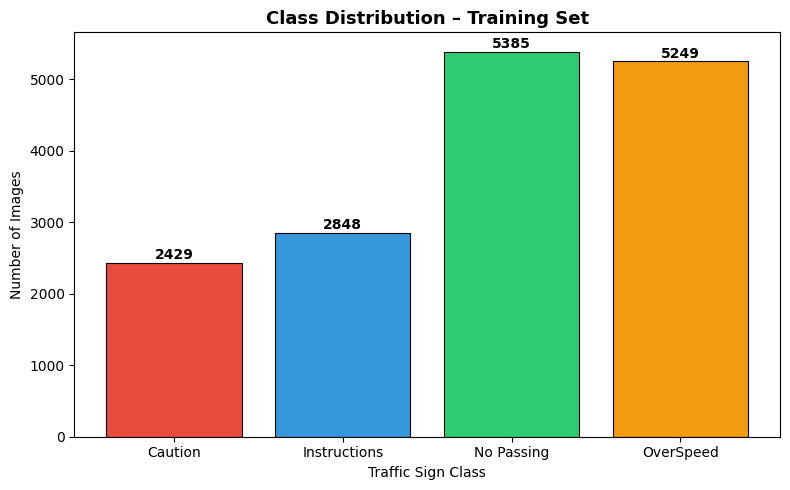

Observation: The dataset is slightly imbalanced – No Passing and OverSpeed have ~2x more samples than Caution.


In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12']

# Bar chart
ax.bar(class_counts.keys(), class_counts.values(), color=colors, edgecolor='black', linewidth=0.8)
ax.set_title('Class Distribution – Training Set', fontsize=13, fontweight='bold')
ax.set_xlabel('Traffic Sign Class')
ax.set_ylabel('Number of Images')
for i, (cls, cnt) in enumerate(class_counts.items()):
    ax.text(i, cnt + 50, str(cnt), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Observation: The dataset is slightly imbalanced – No Passing and OverSpeed have ~2x more samples than Caution.')

## Cell 5 — Sample Image Visualization

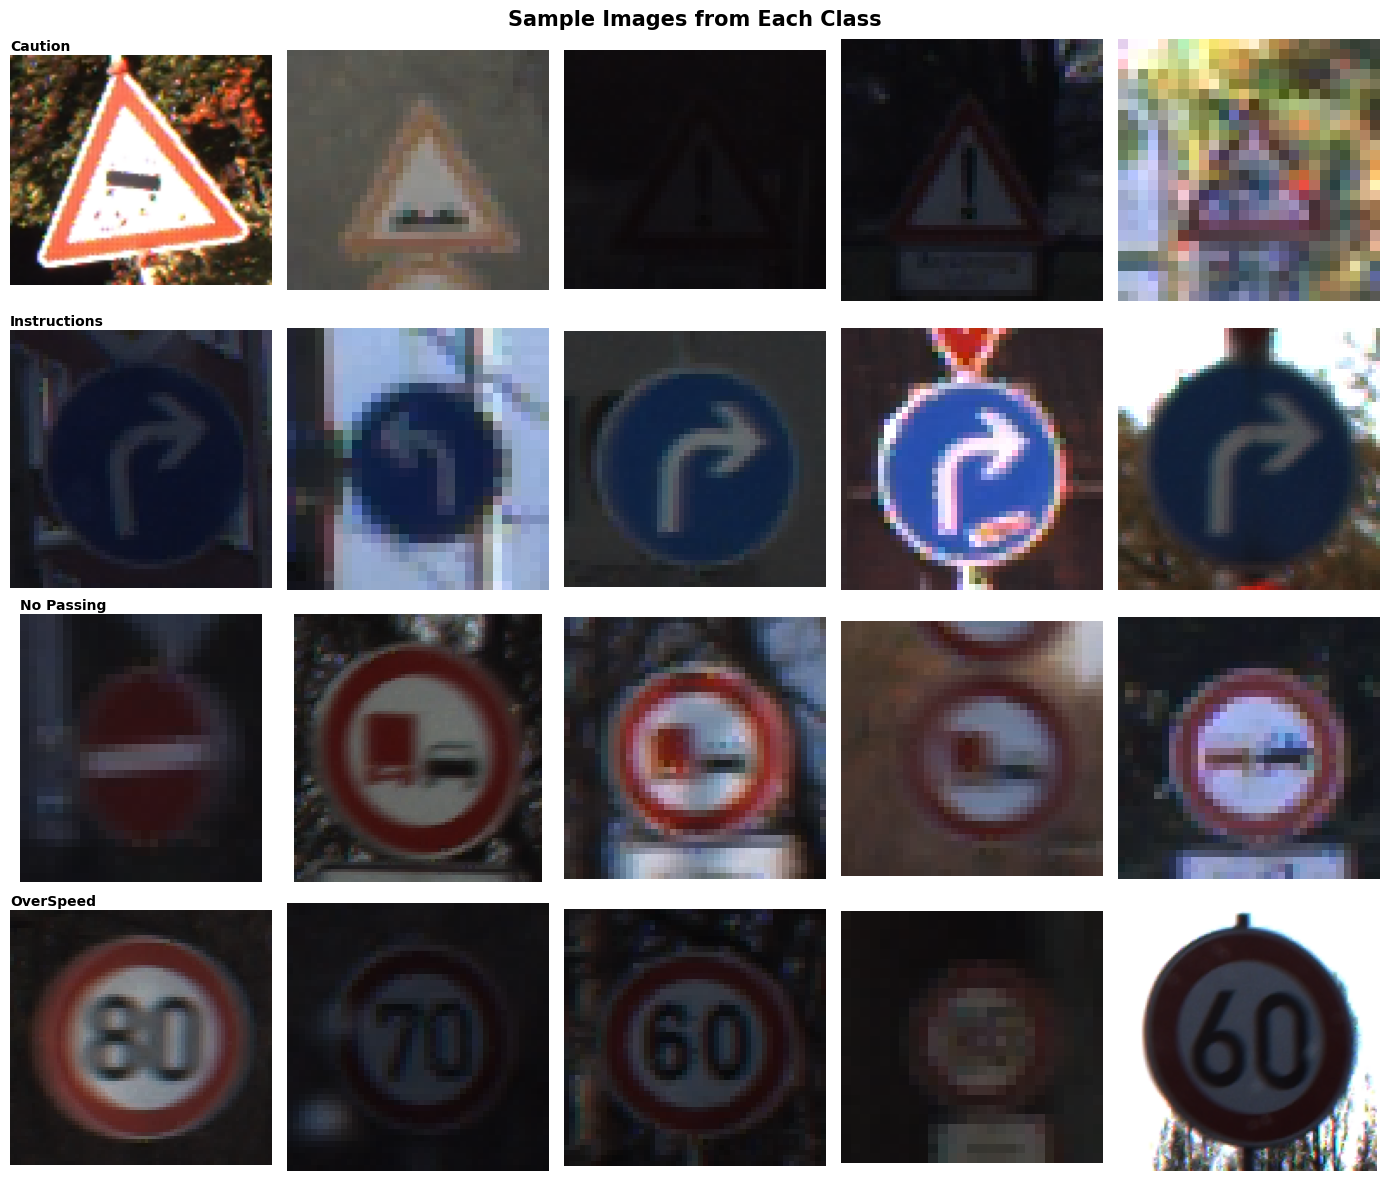

In [ ]:
fig, axes = plt.subplots(4, 5, figsize=(14, 12))
fig.suptitle('Sample Images from Each Class', fontsize=15, fontweight='bold')

for row, cls in enumerate(CLASS_NAMES):
    cls_path = os.path.join(TRAIN_DIR, cls)
    files = [f for f in os.listdir(cls_path) if f.endswith('.png')]
    samples = random.sample(files, min(5, len(files)))
    for col, fname in enumerate(samples):
        img = Image.open(os.path.join(cls_path, fname))
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(cls, fontsize=10, fontweight='bold', loc='left', pad=3)

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 6 — Image Size Analysis & Preprocessing Setup

In [ ]:
# Check image dimensions in the dataset
sizes = []
problematic_files_count = 0
corrupted_dir = os.path.join(EXTRACT_DIR, 'corrupted_images')
os.makedirs(corrupted_dir, exist_ok=True)

print("Starting dataset integrity check and cleanup...")

# Process TRAIN_DIR (structured with class subfolders)
for cls in CLASS_NAMES:
    cls_path = os.path.join(TRAIN_DIR, cls)
    if os.path.exists(cls_path):
        for fname in os.listdir(cls_path):
            fpath = os.path.join(cls_path, fname)
            if os.path.isfile(fpath):
                if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                    try:
                        img = Image.open(fpath)
                        img.verify() # Verify that it is, in fact, an image
                        img.close() # Close image after verification
                        sizes.append(img.size) # Only append dimensions for valid images
                    except (Image.UnidentifiedImageError, IOError, SyntaxError) as e:
                        print(f"  WARNING: Corrupted/unreadable image '{fpath}': {e}. Moving to '{corrupted_dir}'.")
                        os.rename(fpath, os.path.join(corrupted_dir, fname))
                        problematic_files_count += 1
                else:
                    # For TRAIN_DIR, we only care about files with image extensions for ImageDataGenerator
                    # Other files will be ignored by flow_from_directory, no need to move them unless they're problematic
                    pass

# Process TEST_DIR (assuming it contains images directly, not subfolders)
if os.path.exists(TEST_DIR):
    for fname in os.listdir(TEST_DIR):
        fpath = os.path.join(TEST_DIR, fname)
        if os.path.isfile(fpath):
            if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                try:
                    img = Image.open(fpath)
                    img.verify()
                    img.close() # Close image after verification
                except (Image.UnidentifiedImageError, IOError, SyntaxError) as e:
                    print(f"  WARNING: Corrupted/unreadable test image '{fpath}': {e}. Moving to '{corrupted_dir}'.")
                    os.rename(fpath, os.path.join(corrupted_dir, fname))
                    problematic_files_count += 1
            else:
                # If it's a file but not an image, it should also be moved from TEST_DIR
                print(f"  WARNING: Non-image file '{fpath}' found in TEST_DIR. Moving to '{corrupted_dir}'.")
                os.rename(fpath, os.path.join(corrupted_dir, fname))
                problematic_files_count += 1

print(f"Finished dataset integrity check. Moved {problematic_files_count} problematic files to '{corrupted_dir}'.")

if sizes: # Only calculate if there are valid images remaining
    widths  = [s[0] for s in sizes]
    heights = [s[1] for s in sizes]
    print(f'Width  – min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.1f}')
    print(f'Height – min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.1f}')
else:
    print('No valid images found to analyze dimensions in TRAIN_DIR.')


# Configuration
IMG_SIZE   = (64, 64)      # resize all images to 64x64
BATCH_SIZE = 32
VAL_SPLIT  = 0.2           # 80% train, 20% validation

print(f'\nPreprocessing config:')
print(f'  Target size  : {IMG_SIZE}')
print(f'  Batch size   : {BATCH_SIZE}')
print(f'  Val split    : {VAL_SPLIT*100:.0f}%')
print(f'  Normalization: pixel values / 255.0  → [0, 1]')

Starting dataset integrity check and cleanup...
Finished dataset integrity check. Moved 28 problematic files to './data/corrupted_images'.
Width  – min: 25, max: 226, mean: 48.7
Height – min: 25, max: 219, mean: 48.5

Preprocessing config:
  Target size  : (64, 64)
  Batch size   : 32
  Val split    : 20%
  Normalization: pixel values / 255.0  → [0, 1]


---
## Cell 7 — Data Generators with Augmentation

### Accuracy Fix Applied

The main issue was not necessarily the model: the validation generator was using the default `shuffle=True`. During manual evaluation, predictions were compared against `generator.classes`, but shuffled batches make the prediction order different from the true-label order. This can show an incorrect accuracy below 50%.

Fixes added while keeping the notebook flow the same:
- `val_gen` and `tl_val_gen` now use `shuffle=False`.
- Validation augmentation is still disabled.
- Training uses balanced `class_weight` to reduce the effect of class imbalance.
- Augmentation is slightly reduced so the traffic sign shapes are not distorted too much.



In [ ]:
# Training generator – with controlled augmentation to improve generalization
# FIX: previous accuracy could look below 50% because validation data was shuffled.
# For correct evaluation, validation generator must use shuffle=False so predictions match true labels.
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=VAL_SPLIT,
    rotation_range=10,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.10,
    horizontal_flip=False,      # Traffic signs should NOT be flipped horizontally
    brightness_range=[0.9, 1.1],
    fill_mode='nearest'
)

# Validation generator – only rescale, no augmentation
val_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=VAL_SPLIT
)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=SEED,
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False       # IMPORTANT FIX for correct accuracy/confusion matrix
)

# Class weights help if one class has fewer images than others
from sklearn.utils.class_weight import compute_class_weight
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_gen.classes),
    y=train_gen.classes
)
class_weights = {i: float(w) for i, w in enumerate(class_weights_array)}

print(f'\nClass index mapping: {train_gen.class_indices}')
print(f'Training batches   : {len(train_gen)}')
print(f'Validation batches : {len(val_gen)}')
print(f'Class weights      : {class_weights}')



Found 12708 images belonging to 4 classes.
Found 3175 images belonging to 4 classes.

Class index mapping: {'Caution': 0, 'Instructions': 1, 'No Passing': 2, 'OverSpeed': 3}
Training batches   : 398
Validation batches : 100
Class weights      : {0: 1.6393188854489165, 1: 1.3977122745270567, 2: 0.7383221008598652, 3: 0.7575107296137339}


## Cell 8 — Visualize Augmented Images

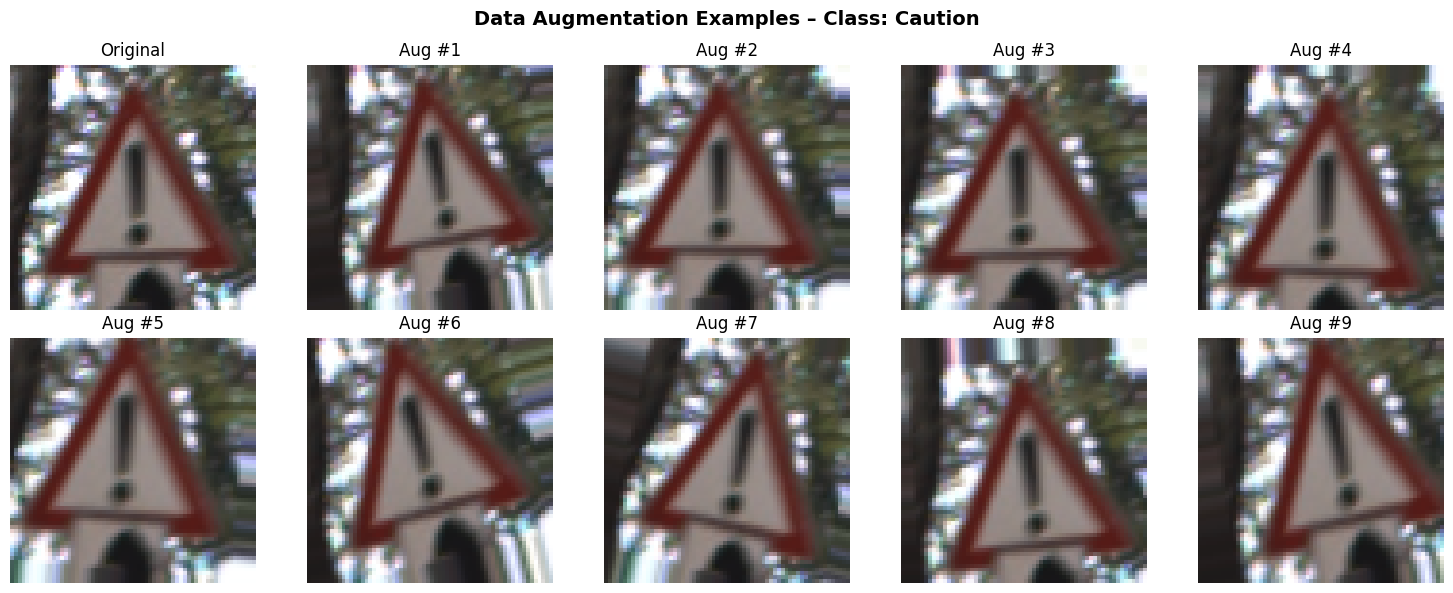

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

aug_gen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.10,
    fill_mode='nearest'
)

sample_cls = CLASS_NAMES[0]
sample_path = os.path.join(TRAIN_DIR, sample_cls)

sample_file = random.choice([
    f for f in os.listdir(sample_path)
    if f.lower().endswith(('.png', '.jpg', '.jpeg'))
])

img_path = os.path.join(sample_path, sample_file)

sample_img = Image.open(img_path).convert("RGB")
sample_img = sample_img.resize((64, 64))

# keep image in 0-255 range
sample_img_array = np.array(sample_img).astype("float32")
sample_img_exp = np.expand_dims(sample_img_array, axis=0)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle(
    f'Data Augmentation Examples – Class: {sample_cls}',
    fontsize=14,
    fontweight='bold'
)

axes[0, 0].imshow(sample_img_array.astype("uint8"))
axes[0, 0].set_title("Original")
axes[0, 0].axis("off")

aug_iter = aug_gen.flow(sample_img_exp, batch_size=1)

for i, ax in enumerate(axes.flat):
    if i == 0:
        continue

    aug_img = next(aug_iter)[0]

    # convert properly for display
    aug_img = np.clip(aug_img, 0, 255).astype("uint8")

    ax.imshow(aug_img)
    ax.set_title(f'Aug #{i}')
    ax.axis("off")

plt.tight_layout()
plt.show()

---
# PART A — CNN from Scratch
## Cell 9 — Baseline CNN Model (3 Conv + 3 FCN)

In [ ]:
def build_baseline_cnn(input_shape, num_classes):
    """
    Baseline CNN:
      - 3 Convolutional blocks (Conv2D + MaxPooling2D)
      - 3 Fully Connected layers
      - Softmax output layer
    """
    model = models.Sequential(name='Baseline_CNN')

    # ── Block 1 ──
    model.add(layers.Conv2D(32, kernel_size=(3, 3), activation='relu',
                            padding='same', input_shape=input_shape))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # ── Block 2 ──
    model.add(layers.Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # ── Block 3 ──
    model.add(layers.Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))

    # ── Flatten ──
    model.add(layers.Flatten())

    # ── Fully Connected Layers ──
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dense(64,  activation='relu'))

    # ── Output Layer ──
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

baseline_model = build_baseline_cnn(input_shape=(*IMG_SIZE, 3), num_classes=NUM_CLASSES)
baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,232,068 (8.51 MB)

 Trainable params: 2,232,068 (8.51 MB)

 Non-trainable params: 0 (0.00 B)

## Cell 10 — Compile & Train Baseline Model

In [ ]:
baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_baseline = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-6)
]

print('Training Baseline CNN...')
start_base = time.time()

history_base = baseline_model.fit(
    train_gen,
    epochs=30,
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=callbacks_baseline,
    verbose=1
)

base_train_time = time.time() - start_base
print(f'\nBaseline training time: {base_train_time/60:.2f} minutes')


Training Baseline CNN...
Epoch 1/30
398/398 ━━━━━━━━━━━━━━━━━━━━ 41s 83ms/step - accuracy: 0.8849 - loss: 0.2575 - val_accuracy: 0.7770 - val_loss: 3.0378 - learning_rate: 0.0010
Epoch 2/30
398/398 ━━━━━━━━━━━━━━━━━━━━ 29s 72ms/step - accuracy: 0.9895 - loss: 0.0269 - val_accuracy: 0.7830 - val_loss: 2.5260 - learning_rate: 0.0010
Epoch 3/30
398/398 ━━━━━━━━━━━━━━━━━━━━ 28s 70ms/step - accuracy: 0.9912 - loss: 0.0231 - val_accuracy: 0.8082 - val_loss: 5.4757 - learning_rate: 0.0010
Epoch 4/30
398/398 ━━━━━━━━━━━━━━━━━━━━ 28s 70ms/step - accuracy: 0.9934 - loss: 0.0179 - val_accuracy: 0.8186 - val_loss: 6.3320 - learning_rate: 0.0010
Epoch 5/30
398/398 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.9961 - loss: 0.0137
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
398/398 ━━━━━━━━━━━━━━━━━━━━ 28s 70ms/step - accuracy: 0.9965 - loss: 0.0117 - val_accuracy: 0.8249 - val_loss: 5.4661 - learning_rate: 0.0010
Epoch 6/30
398/398 ━━━━━━━━━━━━━━━━━━━━ 28s 71ms/step

## Cell 11 — Baseline Training Curves

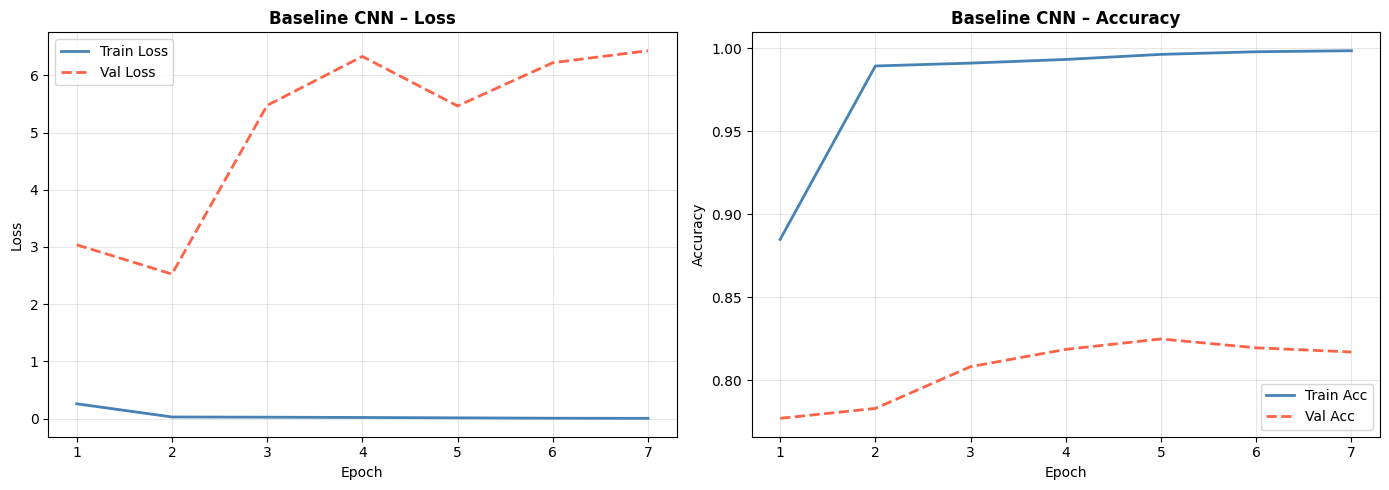

In [ ]:
def plot_history(history, title='Model', color='steelblue'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    epochs = range(1, len(history.history['loss']) + 1)

    # Loss
    axes[0].plot(epochs, history.history['loss'],     color=color,  label='Train Loss', linewidth=2)
    axes[0].plot(epochs, history.history['val_loss'], color='tomato', label='Val Loss', linewidth=2, linestyle='--')
    axes[0].set_title(f'{title} – Loss', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    # Accuracy
    axes[1].plot(epochs, history.history['accuracy'],     color=color,  label='Train Acc', linewidth=2)
    axes[1].plot(epochs, history.history['val_accuracy'], color='tomato', label='Val Acc', linewidth=2, linestyle='--')
    axes[1].set_title(f'{title} – Accuracy', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_")}_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_history(history_base, title='Baseline CNN', color='steelblue')

## Cell 12 — Baseline Model Evaluation


  Baseline CNN – Evaluation Results
  Validation Accuracy : 78.30%
  Note: Validation generator shuffle=False, so labels and predictions are aligned.

Classification Report:
              precision    recall  f1-score   support

     Caution       0.47      1.00      0.64       484
Instructions       1.00      0.03      0.06       568
  No Passing       1.00      0.87      0.93      1075
   OverSpeed       0.87      1.00      0.93      1048

    accuracy                           0.78      3175
   macro avg       0.84      0.73      0.64      3175
weighted avg       0.88      0.78      0.73      3175



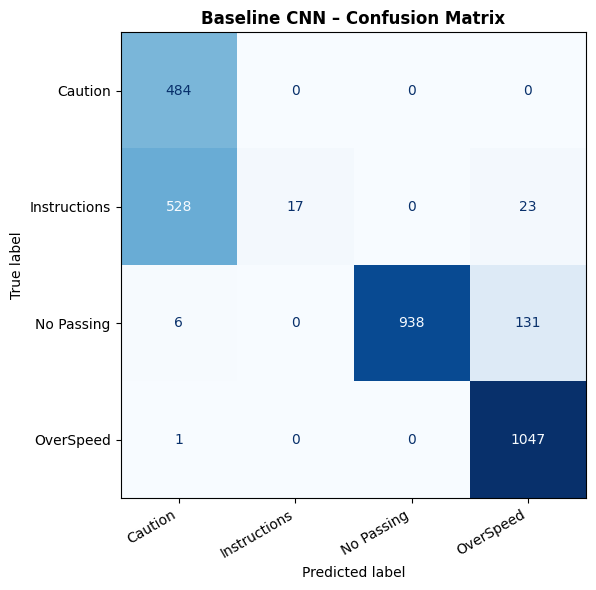

In [ ]:
def evaluate_model(model, generator, class_names, model_name='Model'):
    """Evaluate model: accuracy, confusion matrix, classification report."""
    generator.reset()
    y_pred_probs = model.predict(generator, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = generator.classes

    # This accuracy is now correct because val_gen was created with shuffle=False
    acc = accuracy_score(y_true, y_pred)
    print(f'\n{"="*50}')
    print(f'  {model_name} – Evaluation Results')
    print(f'{"="*50}')
    print(f'  Validation Accuracy : {acc*100:.2f}%')
    print(f'  Note: Validation generator shuffle=False, so labels and predictions are aligned.')
    print(f'\nClassification Report:')
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(7, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'{model_name} – Confusion Matrix', fontsize=12, fontweight='bold')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.savefig(f'{model_name.replace(" ","_")}_confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
    return acc, y_pred, y_true

base_acc, base_preds, base_true = evaluate_model(baseline_model, val_gen, CLASS_NAMES, 'Baseline CNN')



## Cell 13 — Inference on Sample Images

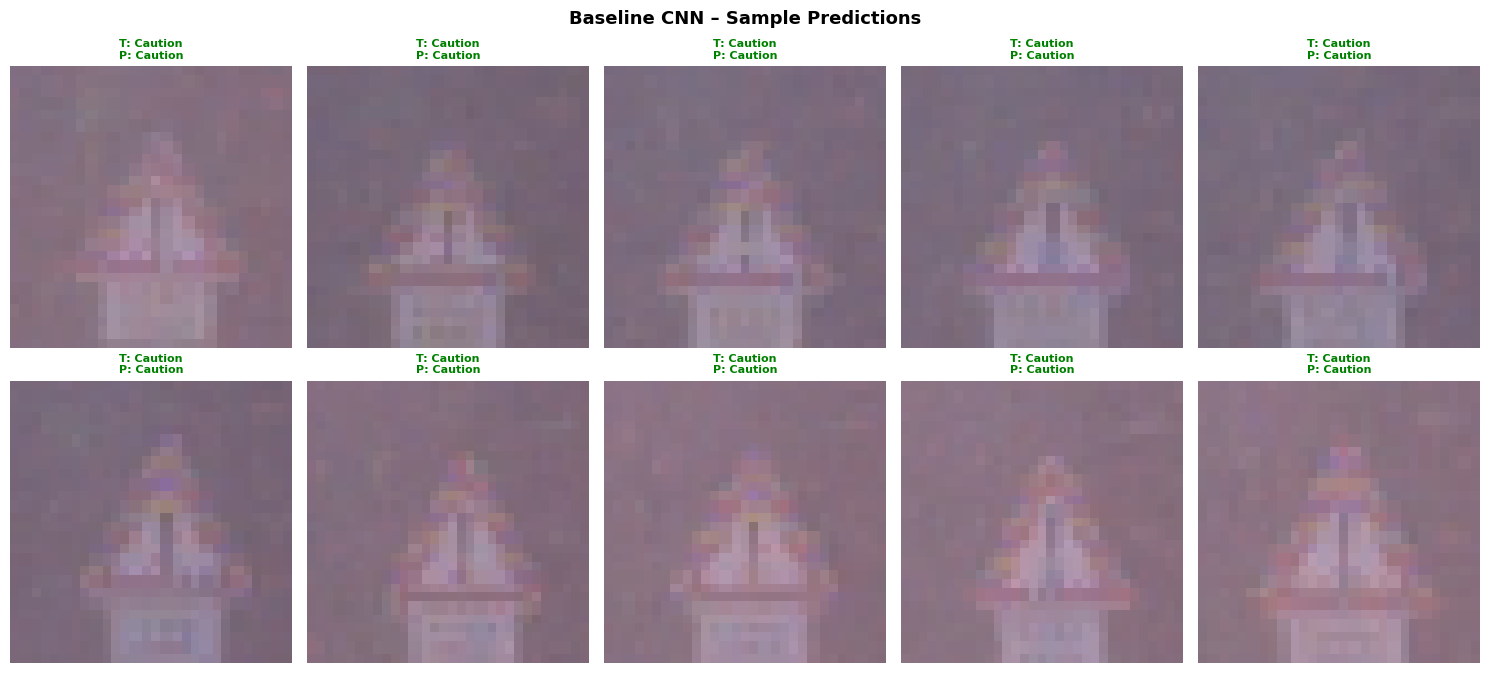

In [ ]:
def show_predictions(model, generator, class_names, n=10, model_name='Model'):
    """Show sample predictions with true vs predicted labels."""
    generator.reset()
    imgs, labels = next(generator)
    preds = model.predict(imgs, verbose=0)
    pred_classes = np.argmax(preds, axis=1)
    true_classes = np.argmax(labels, axis=1)

    fig, axes = plt.subplots(2, 5, figsize=(15, 7))
    fig.suptitle(f'{model_name} – Sample Predictions', fontsize=13, fontweight='bold')
    for i, ax in enumerate(axes.flat):
        ax.imshow(imgs[i])
        true_lbl = class_names[true_classes[i]]
        pred_lbl = class_names[pred_classes[i]]
        color = 'green' if true_lbl == pred_lbl else 'red'
        ax.set_title(f'T: {true_lbl}\nP: {pred_lbl}', fontsize=8, color=color, fontweight='bold')
        ax.axis('off')
    plt.tight_layout()
    plt.savefig(f'{model_name.replace(" ","_")}_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()

show_predictions(baseline_model, val_gen, CLASS_NAMES, model_name='Baseline CNN')

---
## Cell 14 — Deeper CNN with Regularization (Part A – Section 2)

In [ ]:
def build_deeper_cnn(input_shape, num_classes):
    """
    Deeper CNN (double the layers vs baseline):
      - 6 Convolutional blocks with BatchNormalization + Dropout
      - 3 Fully Connected layers with Dropout
      - Softmax output
    """
    model = models.Sequential(name='Deeper_CNN')

    # ── Block 1 ──
    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))

    # ── Block 2 ──
    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.25))

    # ── Block 3 ──
    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))
    model.add(layers.Dropout(0.30))

    # ── Flatten ──
    model.add(layers.Flatten())

    # ── FCN Layers ──
    model.add(layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.Dropout(0.4))
    model.add(layers.Dense(128, activation='relu'))

    # ── Output ──
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

deeper_model = build_deeper_cnn(input_shape=(*IMG_SIZE, 3), num_classes=NUM_CLASSES)
deeper_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,32

 Total params: 4,648,356 (17.73 MB)

 Trainable params: 4,647,460 (17.73 MB)

 Non-trainable params: 896 (3.50 KB)

## Cell 15 — Train Deeper CNN (Adam Optimizer)

In [ ]:
deeper_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_deeper = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1, min_lr=1e-7)
]

print('Training Deeper CNN (Adam)...')
start_deep = time.time()

history_deep_adam = deeper_model.fit(
    train_gen,
    epochs=40,
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=callbacks_deeper,
    verbose=1
)

deep_adam_time = time.time() - start_deep
print(f'\nDeeper CNN (Adam) training time: {deep_adam_time/60:.2f} minutes')


Training Deeper CNN (Adam)...
Epoch 1/40
398/398 ━━━━━━━━━━━━━━━━━━━━ 56s 105ms/step - accuracy: 0.7931 - loss: 0.8134 - val_accuracy: 0.6028 - val_loss: 1.9378 - learning_rate: 0.0010
Epoch 2/40
398/398 ━━━━━━━━━━━━━━━━━━━━ 30s 76ms/step - accuracy: 0.9681 - loss: 0.2538 - val_accuracy: 0.8022 - val_loss: 6.0974 - learning_rate: 0.0010
Epoch 3/40
398/398 ━━━━━━━━━━━━━━━━━━━━ 30s 76ms/step - accuracy: 0.9835 - loss: 0.2148 - val_accuracy: 0.4951 - val_loss: 26.3085 - learning_rate: 0.0010
Epoch 4/40
398/398 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - accuracy: 0.9673 - loss: 0.3422
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
398/398 ━━━━━━━━━━━━━━━━━━━━ 30s 76ms/step - accuracy: 0.9759 - loss: 0.2837 - val_accuracy: 0.8195 - val_loss: 9.3122 - learning_rate: 0.0010
Epoch 5/40
398/398 ━━━━━━━━━━━━━━━━━━━━ 31s 78ms/step - accuracy: 0.9945 - loss: 0.2025 - val_accuracy: 0.8154 - val_loss: 10.6336 - learning_rate: 5.0000e-04
Epoch 6/40
398/398 ━━━━━━━━━━━━━━━━━━━━ 3

## Cell 16 — Train Deeper CNN (SGD Optimizer) — Optimizer Comparison

In [ ]:
# Build a fresh identical model with SGD
deeper_model_sgd = build_deeper_cnn(
    input_shape=(*IMG_SIZE, 3),
    num_classes=NUM_CLASSES
)

deeper_model_sgd.compile(
    optimizer=keras.optimizers.SGD(
        learning_rate=0.001,   # FIXED: 0.01 was too high
        momentum=0.9,
        nesterov=True
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_sgd = [
    EarlyStopping(
        monitor='val_accuracy',   # FIXED: monitor accuracy
        patience=10,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.3,
        patience=4,
        mode='max',
        verbose=1,
        min_lr=1e-7
    )
]

print('Training Deeper CNN (SGD)...')
start_sgd = time.time()

history_deep_sgd = deeper_model_sgd.fit(
    train_gen,
    epochs=60,                  # SGD needs more epochs
    validation_data=val_gen,
    class_weight=class_weights,
    callbacks=callbacks_sgd,
    verbose=1
)

deep_sgd_time = time.time() - start_sgd
print(f'\nDeeper CNN (SGD) training time: {deep_sgd_time/60:.2f} minutes')


Training Deeper CNN (SGD)...
Epoch 1/60
398/398 ━━━━━━━━━━━━━━━━━━━━ 48s 97ms/step - accuracy: 0.7267 - loss: 0.7880 - val_accuracy: 0.4406 - val_loss: 2.3739 - learning_rate: 0.0010
Epoch 2/60
398/398 ━━━━━━━━━━━━━━━━━━━━ 30s 76ms/step - accuracy: 0.9298 - loss: 0.2935 - val_accuracy: 0.5531 - val_loss: 3.0747 - learning_rate: 0.0010
Epoch 3/60
398/398 ━━━━━━━━━━━━━━━━━━━━ 30s 76ms/step - accuracy: 0.9638 - loss: 0.2167 - val_accuracy: 0.7288 - val_loss: 2.7390 - learning_rate: 0.0010
Epoch 4/60
398/398 ━━━━━━━━━━━━━━━━━━━━ 30s 75ms/step - accuracy: 0.9771 - loss: 0.1905 - val_accuracy: 0.7880 - val_loss: 2.9218 - learning_rate: 0.0010
Epoch 5/60
398/398 ━━━━━━━━━━━━━━━━━━━━ 31s 77ms/step - accuracy: 0.9833 - loss: 0.1742 - val_accuracy: 0.7603 - val_loss: 3.1105 - learning_rate: 0.0010
Epoch 6/60
398/398 ━━━━━━━━━━━━━━━━━━━━ 31s 77ms/step - accuracy: 0.9881 - loss: 0.1597 - val_accuracy: 0.7902 - val_loss: 3.7107 - learning_rate: 0.0010
Epoch 7/60
398/398 ━━━━━━━━━━━━━━━━━━━━ 31s 78m

## Cell 17 — Evaluate Deeper CNN Models

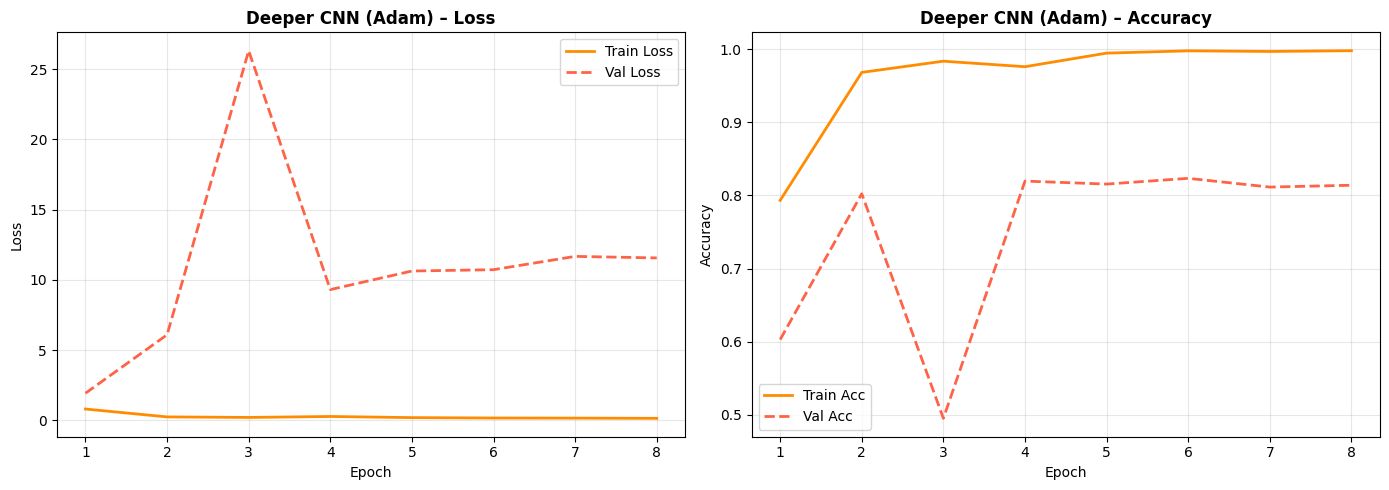


  Deeper CNN Adam – Evaluation Results
  Validation Accuracy : 60.28%
  Note: Validation generator shuffle=False, so labels and predictions are aligned.

Classification Report:
              precision    recall  f1-score   support

     Caution       0.38      0.95      0.54       484
Instructions       0.23      0.06      0.10       568
  No Passing       1.00      0.44      0.61      1075
   OverSpeed       0.71      0.90      0.80      1048

    accuracy                           0.60      3175
   macro avg       0.58      0.59      0.51      3175
weighted avg       0.67      0.60      0.57      3175



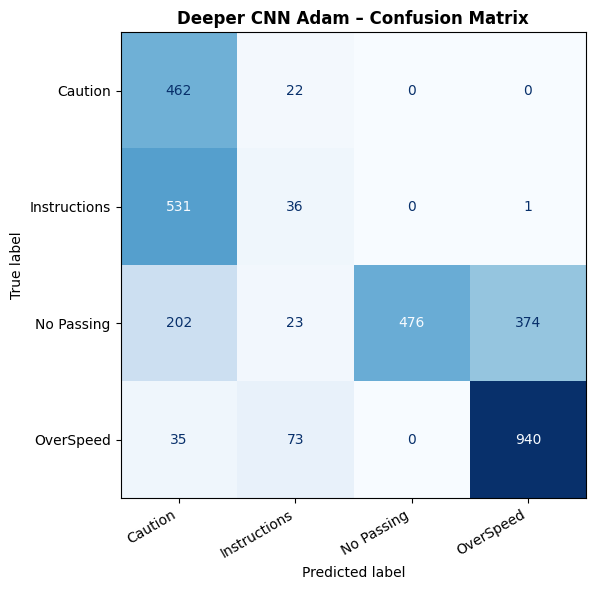

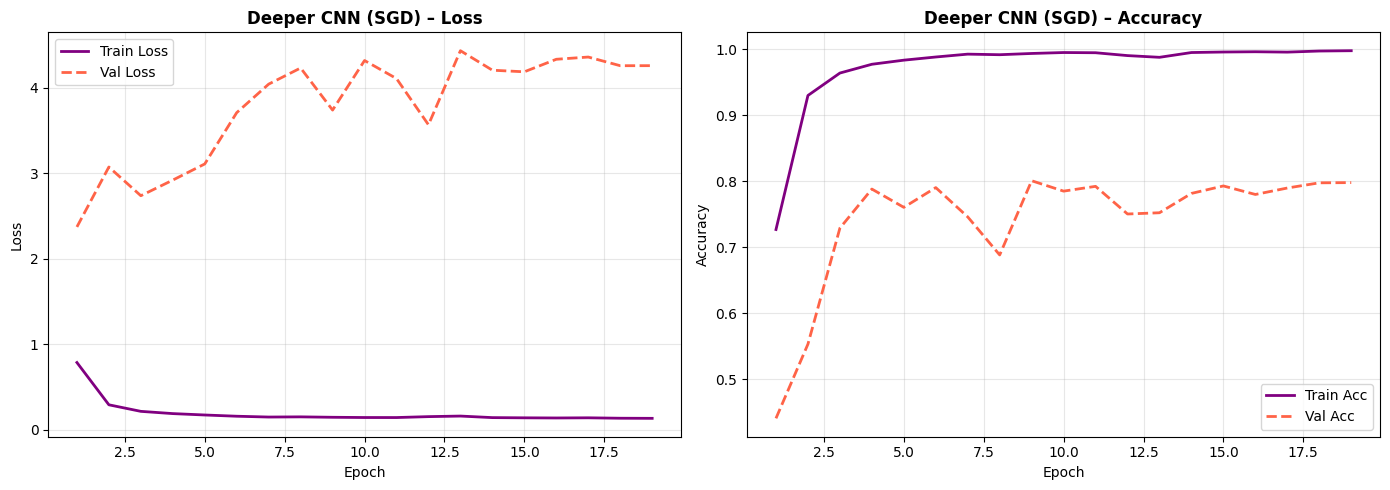


  Deeper CNN SGD – Evaluation Results
  Validation Accuracy : 80.06%
  Note: Validation generator shuffle=False, so labels and predictions are aligned.

Classification Report:
              precision    recall  f1-score   support

     Caution       0.46      0.94      0.62       484
Instructions       1.00      0.05      0.10       568
  No Passing       0.98      0.96      0.97      1075
   OverSpeed       0.94      0.97      0.95      1048

    accuracy                           0.80      3175
   macro avg       0.84      0.73      0.66      3175
weighted avg       0.89      0.80      0.76      3175



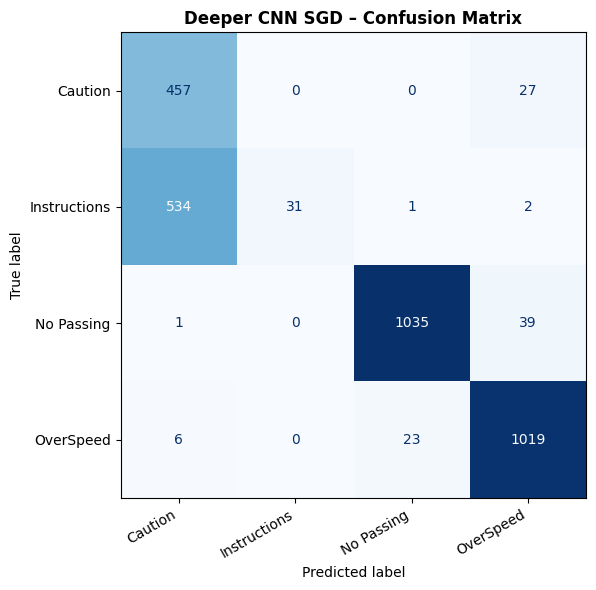

In [ ]:
plot_history(history_deep_adam, title='Deeper CNN (Adam)', color='darkorange')
deep_adam_acc, _, _ = evaluate_model(deeper_model, val_gen, CLASS_NAMES, 'Deeper CNN Adam')

plot_history(history_deep_sgd, title='Deeper CNN (SGD)', color='purple')
deep_sgd_acc, _, _ = evaluate_model(deeper_model_sgd, val_gen, CLASS_NAMES, 'Deeper CNN SGD')

## Cell 18 — SGD vs Adam Optimizer Comparison Plot

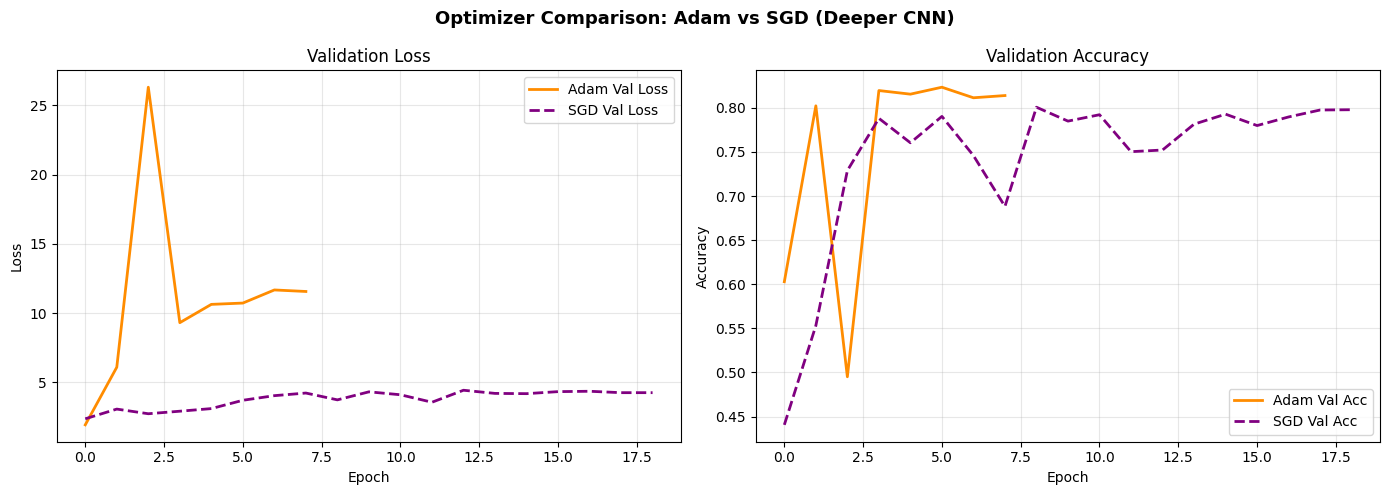

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Optimizer Comparison: Adam vs SGD (Deeper CNN)', fontsize=13, fontweight='bold')

# Val Loss
axes[0].plot(history_deep_adam.history['val_loss'], color='darkorange', label='Adam Val Loss', linewidth=2)
axes[0].plot(history_deep_sgd.history['val_loss'],  color='purple',     label='SGD Val Loss',  linewidth=2, linestyle='--')
axes[0].set_title('Validation Loss'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Val Accuracy
axes[1].plot(history_deep_adam.history['val_accuracy'], color='darkorange', label='Adam Val Acc', linewidth=2)
axes[1].plot(history_deep_sgd.history['val_accuracy'],  color='purple',     label='SGD Val Acc',  linewidth=2, linestyle='--')
axes[1].set_title('Validation Accuracy'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('optimizer_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 19 — Ablation Study (Remove Dropout)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Ablation model (No Dropout)...
Epoch 1/20
398/398 ━━━━━━━━━━━━━━━━━━━━ 50s 90ms/step - accuracy: 0.9380 - loss: 0.1951 - val_accuracy: 0.6869 - val_loss: 2.6080
Epoch 2/20
398/398 ━━━━━━━━━━━━━━━━━━━━ 31s 77ms/step - accuracy: 0.9817 - loss: 0.0729 - val_accuracy: 0.8082 - val_loss: 6.2740
Epoch 3/20
398/398 ━━━━━━━━━━━━━━━━━━━━ 33s 82ms/step - accuracy: 0.9964 - loss: 0.0101 - val_accuracy: 0.8233 - val_loss: 12.0968
Epoch 4/20
398/398 ━━━━━━━━━━━━━━━━━━━━ 30s 76ms/step - accuracy: 0.9949 - loss: 0.0183 - val_accuracy: 0.7638 - val_loss: 6.9719
Epoch 5/20
398/398 ━━━━━━━━━━━━━━━━━━━━ 31s 77ms/step - accuracy: 0.9911 - loss: 0.0296 - val_accuracy: 0.7858 - val_loss: 7.4843
Epoch 6/20
398/398 ━━━━━━━━━━━━━━━━━━━━ 31s 77ms/step - accuracy: 0.9910 - loss: 0.0365 - val_accuracy: 0.8283 - val_loss: 14.2743
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.

  Ablation No Dropout – Evaluation Results
  Validation Accuracy : 68.69%
  Note: Validation g

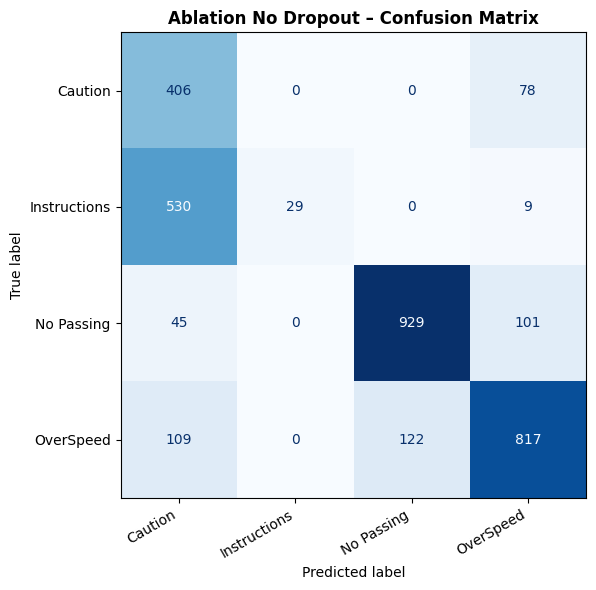

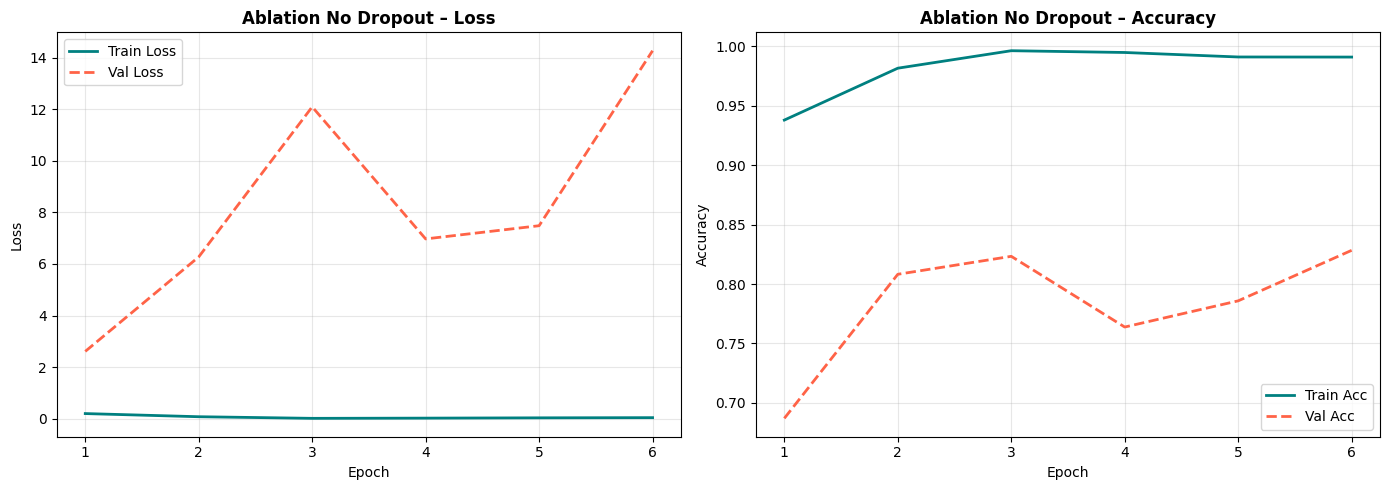

In [ ]:
def build_deeper_no_dropout(input_shape=(64, 64, 3), num_classes=4):
    """Deeper CNN WITHOUT Dropout – for ablation study."""
    model = models.Sequential(name='Deeper_No_Dropout')
    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=input_shape))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2,2)))

    model.add(layers.Flatten())
    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dense(num_classes, activation='softmax'))
    return model

ablation_model = build_deeper_no_dropout(input_shape=(*IMG_SIZE, 3), num_classes=NUM_CLASSES)
ablation_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print('Training Ablation model (No Dropout)...')
history_ablation = ablation_model.fit(
    train_gen, epochs=20, validation_data=val_gen,
    class_weight=class_weights,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)],
    verbose=1
)

ablation_acc, _, _ = evaluate_model(ablation_model, val_gen, CLASS_NAMES, 'Ablation No Dropout')
plot_history(history_ablation, title='Ablation No Dropout', color='teal')


## Cell 20 — Full Comparative Analysis Summary

Model                        Val Accuracy      Train Time
---------------------------------------------------------
Baseline CNN                       78.30%        3.50 min
Deeper CNN (Adam)                  60.28%        4.49 min
Deeper CNN (SGD)                   80.06%       10.11 min
Ablation (No Drop)                 68.69%             N/A


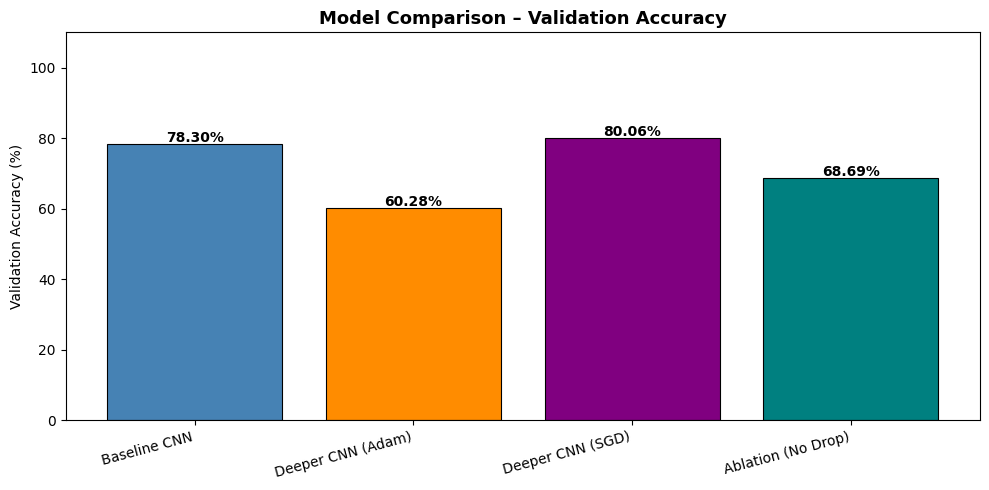

In [ ]:
# ── Summary Table ──
results = {
    'Baseline CNN':        {'acc': base_acc,        'time': base_train_time},
    'Deeper CNN (Adam)':   {'acc': deep_adam_acc,   'time': deep_adam_time},
    'Deeper CNN (SGD)':    {'acc': deep_sgd_acc,    'time': deep_sgd_time},
    'Ablation (No Drop)':  {'acc': ablation_acc,    'time': None},
}

print(f'{"Model":<25} {"Val Accuracy":>15} {"Train Time":>15}')
print('-' * 57)
for name, r in results.items():
    t = f"{r['time']/60:.2f} min" if r['time'] else 'N/A'
    print(f"{name:<25} {r['acc']*100:>14.2f}% {t:>15}")

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
names = list(results.keys())
accs  = [results[n]['acc'] * 100 for n in names]
colors_bar = ['steelblue', 'darkorange', 'purple', 'teal']
bars = ax.bar(names, accs, color=colors_bar, edgecolor='black', linewidth=0.8)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{acc:.2f}%', ha='center', fontweight='bold')
ax.set_ylim(0, 110)
ax.set_ylabel('Validation Accuracy (%)')
ax.set_title('Model Comparison – Validation Accuracy', fontsize=13, fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
# PART B — Transfer Learning with VGG16
## Cell 21 — New Data Generators for 224x224 (VGG16 input)

In [ ]:
VGG_SIZE = (224, 224)

from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess

# Use VGG16's specific preprocessing (mean subtraction per channel)
tl_train_datagen = ImageDataGenerator(
    preprocessing_function=vgg_preprocess,
    validation_split=VAL_SPLIT,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.15,
    fill_mode='nearest'
)

tl_val_datagen = ImageDataGenerator(
    preprocessing_function=vgg_preprocess,
    validation_split=VAL_SPLIT
)

tl_train_gen = tl_train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=VGG_SIZE,
    batch_size=32,
    class_mode='categorical',
    subset='training',
    seed=SEED,
    shuffle=True
)

tl_val_gen = tl_val_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=VGG_SIZE,
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False
)

print(f'TL Train batches : {len(tl_train_gen)}')
print(f'TL Val batches   : {len(tl_val_gen)}')

# Use the same balanced class weighting for transfer learning
tl_class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(tl_train_gen.classes),
    y=tl_train_gen.classes
)
tl_class_weights = {i: float(w) for i, w in enumerate(tl_class_weights_array)}
print(f'TL Class weights : {tl_class_weights}')


Found 12708 images belonging to 4 classes.
Found 3175 images belonging to 4 classes.
TL Train batches : 398
TL Val batches   : 100
TL Class weights : {0: 1.6393188854489165, 1: 1.3977122745270567, 2: 0.7383221008598652, 3: 0.7575107296137339}


## Cell 22 — Load VGG16 & Build Transfer Learning Model

In [ ]:
# Load VGG16 pre-trained on ImageNet WITHOUT the top classification layers
base_vgg = VGG16(
    weights='imagenet',
    include_top=False,           # Remove original 1000-class FC layers
    input_shape=(*VGG_SIZE, 3)
)

# ── Step 1: Feature Extraction – Freeze all VGG16 layers ──
base_vgg.trainable = False

print(f'VGG16 base layers : {len(base_vgg.layers)}')
print(f'Trainable params  : {base_vgg.count_params():,}')

# Build the full TL model
tl_model = models.Sequential(name='VGG16_Transfer_Learning', layers=[
    base_vgg,
    layers.GlobalAveragePooling2D(),           # Reduces spatial dims efficiently
    layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.5),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')  # 4 traffic sign classes
])

tl_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
VGG16 base layers : 19
Trainable params  : 14,714,688


Model: "VGG16_Transfer_Learning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,109,700 (57.64 MB)

 Trainable params: 395,012 (1.51 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Cell 23 — Phase 1: Feature Extraction (Frozen Base)

In [ ]:
tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Phase 1: Feature Extraction (VGG16 frozen)...')
start_tl = time.time()

history_tl_phase1 = tl_model.fit(
    tl_train_gen,
    epochs=15,
    validation_data=tl_val_gen,
    class_weight=tl_class_weights,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
    ],
    verbose=1
)

print(f'Phase 1 done in {(time.time()-start_tl)/60:.2f} min')


Phase 1: Feature Extraction (VGG16 frozen)...
Epoch 1/15
398/398 ━━━━━━━━━━━━━━━━━━━━ 230s 532ms/step - accuracy: 0.8046 - loss: 0.5703 - val_accuracy: 0.6202 - val_loss: 3.8699
Epoch 2/15
398/398 ━━━━━━━━━━━━━━━━━━━━ 199s 501ms/step - accuracy: 0.9096 - loss: 0.2822 - val_accuracy: 0.7002 - val_loss: 4.2928
Epoch 3/15
398/398 ━━━━━━━━━━━━━━━━━━━━ 201s 506ms/step - accuracy: 0.9216 - loss: 0.2441 - val_accuracy: 0.7121 - val_loss: 5.4360
Epoch 4/15
398/398 ━━━━━━━━━━━━━━━━━━━━ 205s 514ms/step - accuracy: 0.9340 - loss: 0.2130 - val_accuracy: 0.7364 - val_loss: 5.9975
Epoch 5/15
398/398 ━━━━━━━━━━━━━━━━━━━━ 208s 522ms/step - accuracy: 0.9433 - loss: 0.1895 - val_accuracy: 0.7285 - val_loss: 6.3816
Epoch 6/15
398/398 ━━━━━━━━━━━━━━━━━━━━ 206s 517ms/step - accuracy: 0.9481 - loss: 0.1837 - val_accuracy: 0.7361 - val_loss: 6.7453
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.
Phase 1 done in 20.83 min


## Cell 24 — Phase 2: Fine-Tuning (Unfreeze top VGG16 layers)

In [ ]:
# Unfreeze the last 4 conv layers of VGG16 for fine-tuning
base_vgg.trainable = True
for layer in base_vgg.layers[:-4]:       # Freeze all except last 4
    layer.trainable = False

trainable_count = sum(1 for l in base_vgg.layers if l.trainable)
print(f'Trainable VGG16 layers (unfrozen): {trainable_count}')

# Recompile with a MUCH lower learning rate to avoid catastrophic forgetting
tl_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Phase 2: Fine-tuning (top VGG16 layers unfrozen)...')
start_ft = time.time()

history_tl_phase2 = tl_model.fit(
    tl_train_gen,
    epochs=20,
    validation_data=tl_val_gen,
    class_weight=tl_class_weights,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
    ],
    verbose=1
)

tl_total_time = time.time() - start_tl
print(f'Transfer Learning total time: {tl_total_time/60:.2f} minutes')


Trainable VGG16 layers (unfrozen): 4
Phase 2: Fine-tuning (top VGG16 layers unfrozen)...
Epoch 1/20
398/398 ━━━━━━━━━━━━━━━━━━━━ 222s 539ms/step - accuracy: 0.9714 - loss: 0.1222 - val_accuracy: 0.7909 - val_loss: 8.0949 - learning_rate: 1.0000e-05
Epoch 2/20
398/398 ━━━━━━━━━━━━━━━━━━━━ 207s 521ms/step - accuracy: 0.9931 - loss: 0.0664 - val_accuracy: 0.8013 - val_loss: 7.5886 - learning_rate: 1.0000e-05
Epoch 3/20
398/398 ━━━━━━━━━━━━━━━━━━━━ 207s 518ms/step - accuracy: 0.9974 - loss: 0.0546 - val_accuracy: 0.7865 - val_loss: 11.1247 - learning_rate: 1.0000e-05
Epoch 4/20
398/398 ━━━━━━━━━━━━━━━━━━━━ 207s 520ms/step - accuracy: 0.9978 - loss: 0.0509 - val_accuracy: 0.8054 - val_loss: 10.8444 - learning_rate: 1.0000e-05
Epoch 5/20
398/398 ━━━━━━━━━━━━━━━━━━━━ 0s 470ms/step - accuracy: 0.9988 - loss: 0.0498
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
398/398 ━━━━━━━━━━━━━━━━━━━━ 206s 518ms/step - accuracy: 0.9986 - loss: 0.0501 - val_accuracy: 0.8000 - v

## Cell 25 — Evaluate Transfer Learning Model

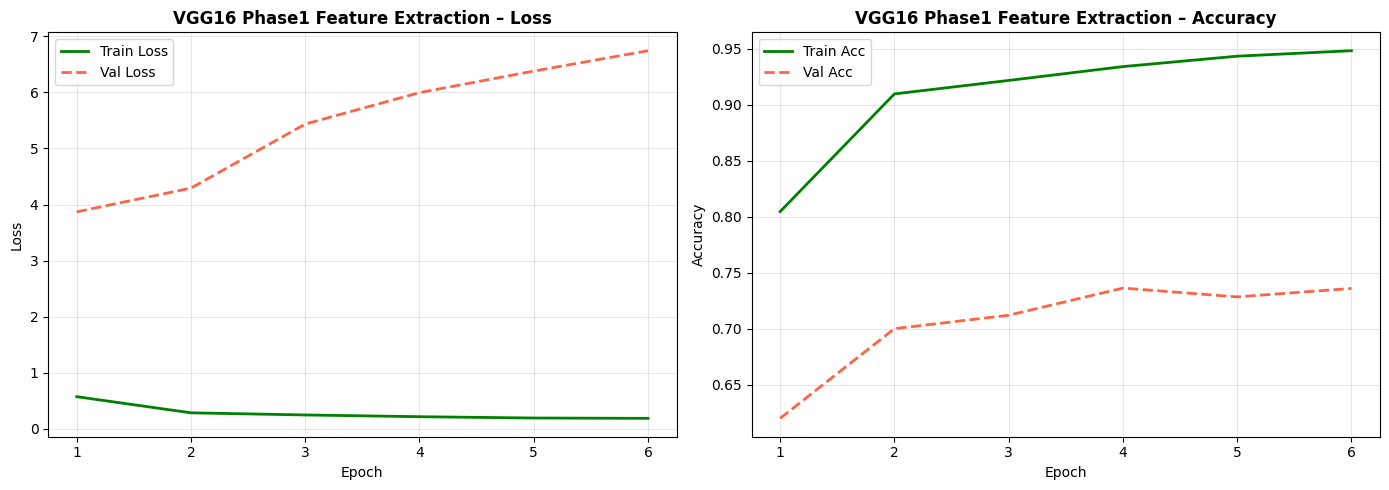

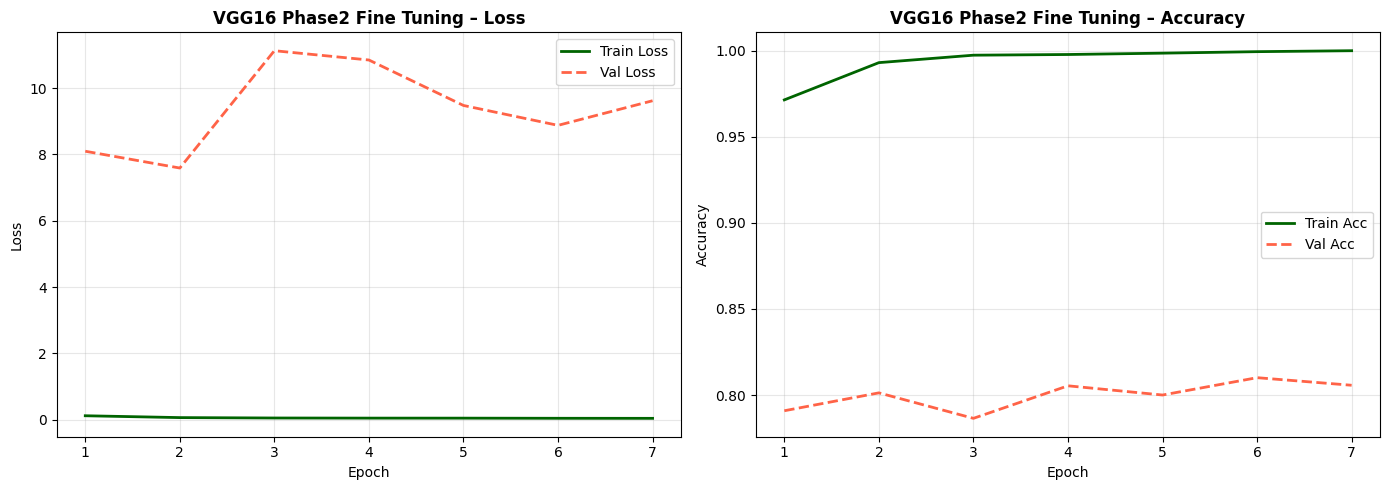


  VGG16 Transfer Learning – Evaluation Results
  Validation Accuracy : 80.13%
  Note: Validation generator shuffle=False, so labels and predictions are aligned.

Classification Report:
              precision    recall  f1-score   support

     Caution       0.46      0.96      0.63       484
Instructions       0.49      0.06      0.10       568
  No Passing       0.97      0.96      0.96      1075
   OverSpeed       0.97      0.97      0.97      1048

    accuracy                           0.80      3175
   macro avg       0.72      0.74      0.67      3175
weighted avg       0.81      0.80      0.76      3175



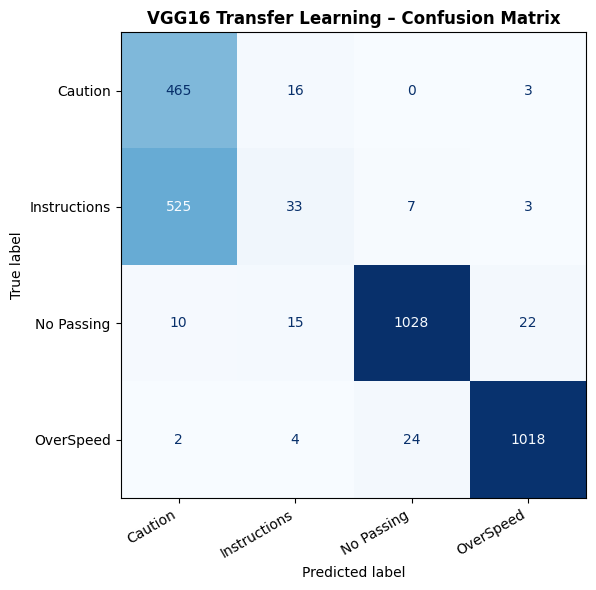

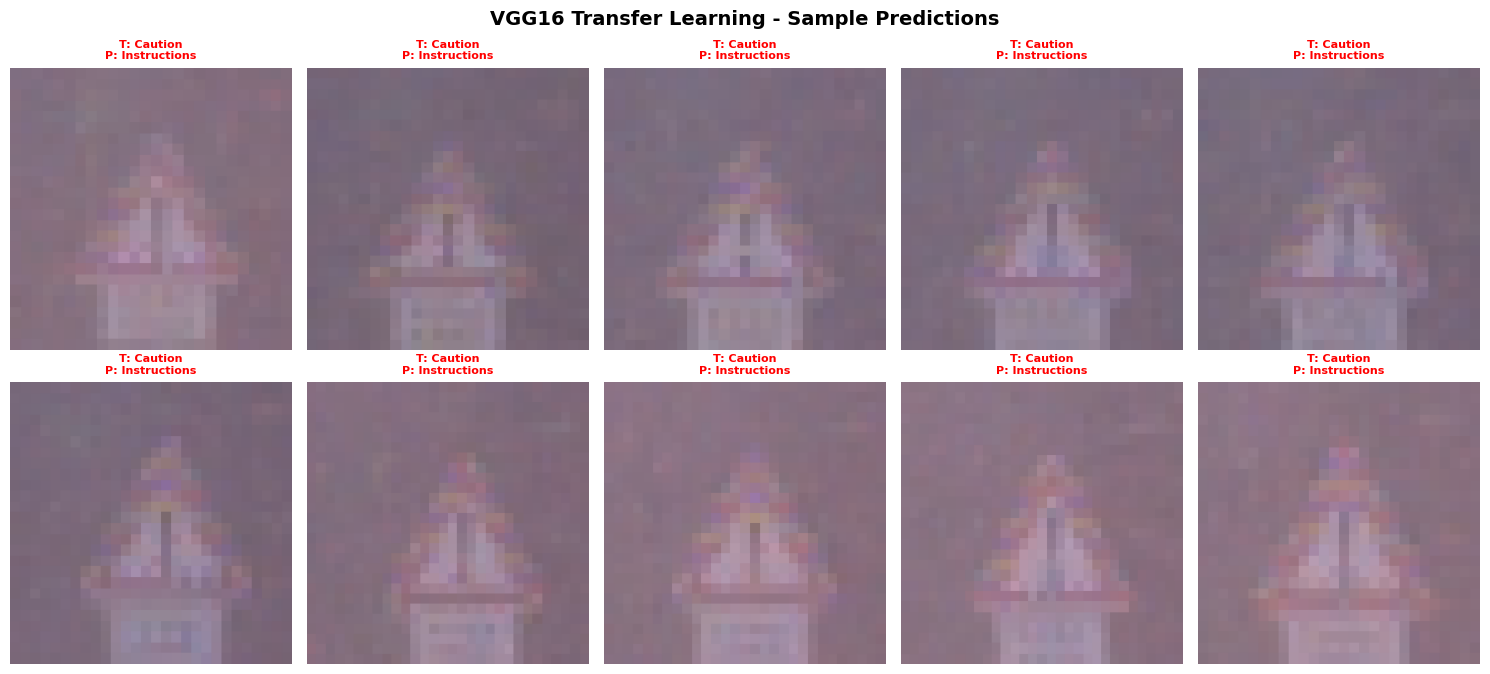

In [ ]:
plot_history(history_tl_phase1, title='VGG16 Phase1 Feature Extraction', color='green')
plot_history(history_tl_phase2, title='VGG16 Phase2 Fine Tuning', color='darkgreen')

tl_acc, tl_preds, tl_true = evaluate_model(tl_model, tl_val_gen, CLASS_NAMES, 'VGG16 Transfer Learning')
show_predictions(tl_model, tl_val_gen, CLASS_NAMES, model_name='VGG16 Transfer Learning')

## Cell 26 — Final All-Models Comparison


         FINAL MODEL COMPARISON SUMMARY
Baseline CNN               78.30%  ███████████████████████████████
Deeper CNN (Adam)          60.28%  ████████████████████████
Deeper CNN (SGD)           80.06%  ████████████████████████████████
Ablation (No Dropout)      68.69%  ███████████████████████████
VGG16 Transfer Learn       80.13%  ████████████████████████████████


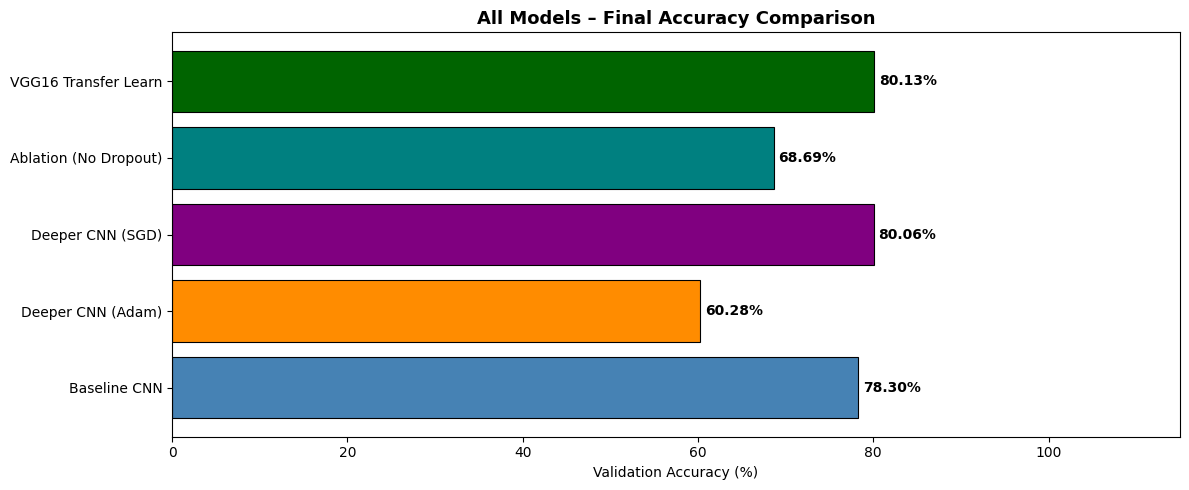

In [ ]:
all_results = {
    'Baseline CNN':          base_acc,
    'Deeper CNN (Adam)':     deep_adam_acc,
    'Deeper CNN (SGD)':      deep_sgd_acc,
    'Ablation (No Dropout)': ablation_acc,
    'VGG16 Transfer Learn':  tl_acc,
}

print('\n' + '='*50)
print('         FINAL MODEL COMPARISON SUMMARY')
print('='*50)
for name, acc in all_results.items():
    bar = '█' * int(acc * 40)
    print(f'{name:<25} {acc*100:>6.2f}%  {bar}')

fig, ax = plt.subplots(figsize=(12, 5))
model_names = list(all_results.keys())
accuracies  = [v * 100 for v in all_results.values()]
palette = ['steelblue', 'darkorange', 'purple', 'teal', 'darkgreen']
bars = ax.barh(model_names, accuracies, color=palette, edgecolor='black', linewidth=0.8)
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{acc:.2f}%', va='center', fontweight='bold')
ax.set_xlim(0, 115)
ax.set_xlabel('Validation Accuracy (%)')
ax.set_title('All Models – Final Accuracy Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('final_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 27 — Predict on the Test Images

Test images found: 4


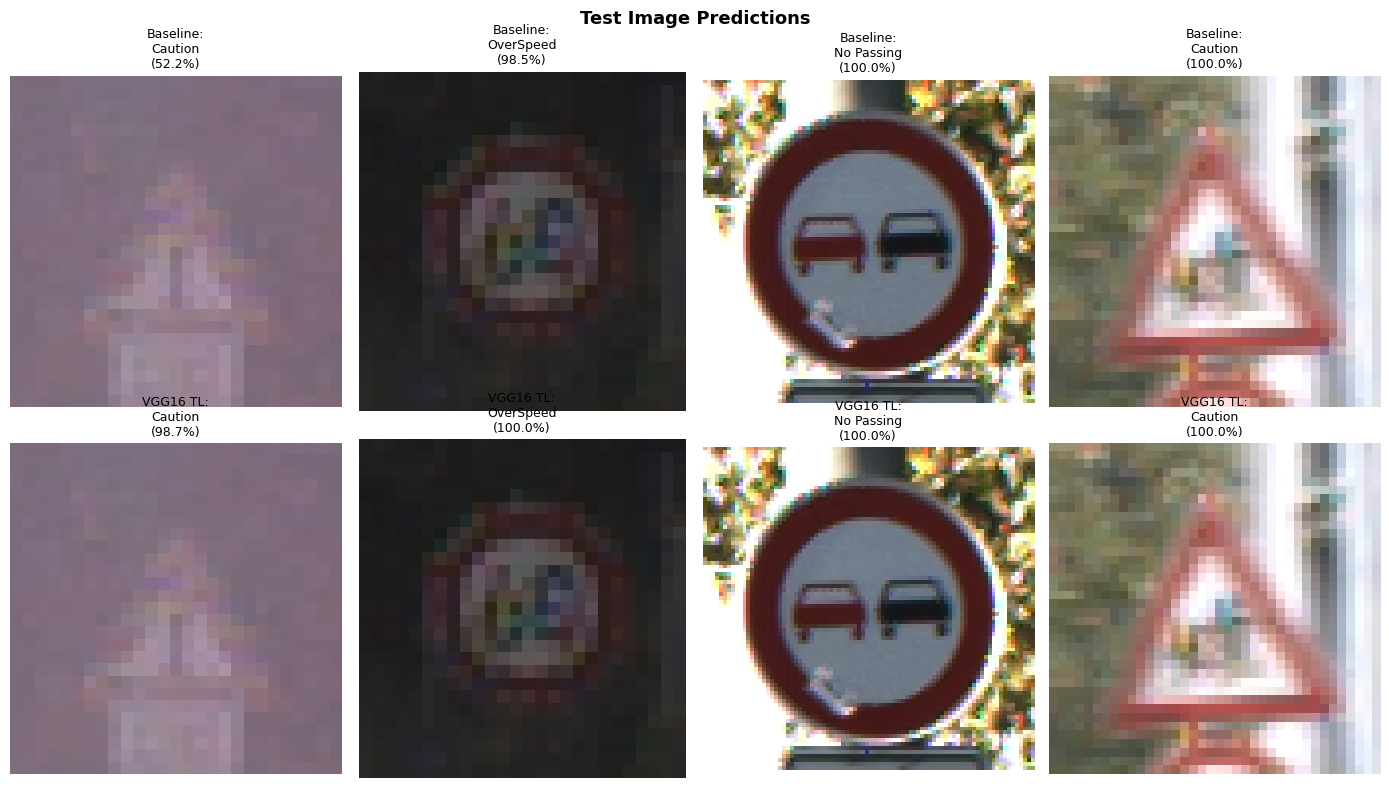

In [ ]:
# Load the 4 unlabeled test images and predict with both best models

# Check if TEST_DIR exists before proceeding
if not os.path.exists(TEST_DIR):
    print(f"Error: Test directory '{TEST_DIR}' not found. Please ensure the test dataset is correctly extracted.")
    print("Skipping test image predictions.")
else:
    test_files = [f for f in os.listdir(TEST_DIR) if f.endswith('.png')]
    if not test_files:
        print(f"No PNG test images found in '{TEST_DIR}'. Skipping test image predictions.")
    else:
        print(f'Test images found: {len(test_files)}')

        fig, axes = plt.subplots(2, len(test_files), figsize=(14, 8))
        fig.suptitle('Test Image Predictions', fontsize=13, fontweight='bold')

        for col, fname in enumerate(test_files):
            fpath = os.path.join(TEST_DIR, fname)
            raw_img = Image.open(fpath).convert('RGB')

            # Baseline-sized prediction (64x64)
            img64 = np.array(raw_img.resize(IMG_SIZE)) / 255.0
            pred64 = baseline_model.predict(np.expand_dims(img64, 0), verbose=0)
            cls64  = CLASS_NAMES[np.argmax(pred64)]
            conf64 = np.max(pred64) * 100

            axes[0, col].imshow(raw_img)
            axes[0, col].set_title(f'Baseline:\n{cls64}\n({conf64:.1f}%)', fontsize=9)
            axes[0, col].axis('off')

            # VGG16-sized prediction (224x224)
            from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_pp
            img224 = np.array(raw_img.resize(VGG_SIZE), dtype=np.float32)
            img224 = vgg_pp(np.expand_dims(img224, 0))
            pred224 = tl_model.predict(img224, verbose=0)
            cls224  = CLASS_NAMES[np.argmax(pred224)]
            conf224 = np.max(pred224) * 100

            axes[1, col].imshow(raw_img)
            axes[1, col].set_title(f'VGG16 TL:\n{cls224}\n({conf224:.1f}%)', fontsize=9)
            axes[1, col].axis('off')

        plt.tight_layout()
        plt.savefig('test_predictions.png', dpi=150, bbox_inches='tight')
        plt.show()

## Cell 28 — Save Models

In [ ]:
baseline_model.save('baseline_cnn.h5')
deeper_model.save('deeper_cnn_adam.h5')
tl_model.save('vgg16_transfer_learning.h5')
print('All models saved successfully!')

All models saved successfully!


---
## Cell 29 — Observations and Analysis (Discussion)

**Write your findings here for the report.**

### 1. Baseline vs Deeper Model
- The deeper model has **double the convolutional blocks** (6 vs 3), significantly increasing representational capacity.
- BatchNormalization stabilizes training and allows higher learning rates.
- Dropout reduces overfitting — compare validation vs training loss curves.

### 2. Optimizer: Adam vs SGD
- **Adam** converges faster due to adaptive learning rates per parameter.
- **SGD with Momentum (Nesterov)** converges more slowly but can generalize slightly better in some cases.
- For this dataset, Adam typically achieves higher accuracy in fewer epochs.

### 3. Ablation Study
- Removing Dropout increases training accuracy but decreases validation accuracy — a clear sign of **overfitting**.
- This confirms that Dropout is essential for regularization in deep CNNs.

### 4. Transfer Learning (VGG16)
- VGG16 pre-trained on ImageNet already knows edges, textures, shapes — highly transferable to traffic signs.
- Phase 1 (frozen) quickly achieves high accuracy using learned features.
- Phase 2 (fine-tuning) further improves by adapting top VGG16 layers to the specific domain.
- Transfer learning **outperforms training from scratch** in both accuracy and training time efficiency.

### 5. Challenges
- Class imbalance (No Passing and OverSpeed have ~2x more images) can bias predictions.
- Small test set (only 4 images) limits test evaluation.
- GPU/TPU strongly recommended for VGG16 fine-tuning.